# Project 4 — Visualizing Linear vs. Nonlinear Decision Boundaries

## Project Description

**Objective**: Develop geometric intuition for when linear models succeed or fail.

**Using Python, NumPy, Matplotlib, and scikit-learn**:

- Create or generate a linearly separable 2D dataset and train a Perceptron. Plot the data and its learned decision boundary.
- Create the XOR dataset and train the same Perceptron. Plot the data and the learned boundary.
- Compare the two results:
  - Which dataset converges?
  - Which does not?
- How does the learned boundary differ?

Write a short reflection explaining why the failure on XOR is due to model capacity rather than poor training.

## My Solution

In [132]:
from pprint import pprint

import numpy as np
import pandas as pd

from matplotlib.figure import Figure
from IPython.display import display
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

In [133]:
# 1. Generate 2D linearly separable dataset
X, y = make_blobs(
    n_samples=200,  # Total number of points
    n_features=2,  # 2D dataset
    centers=2,  # 2 classes
    cluster_std=0.9,  # Controls cluster tightness (smaller = more separated)
    center_box=(-5.0, 5.0),  # Spread out cluster centers
    random_state=42,  # Ensures reproducibility
)

In [134]:
y

array([1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0])

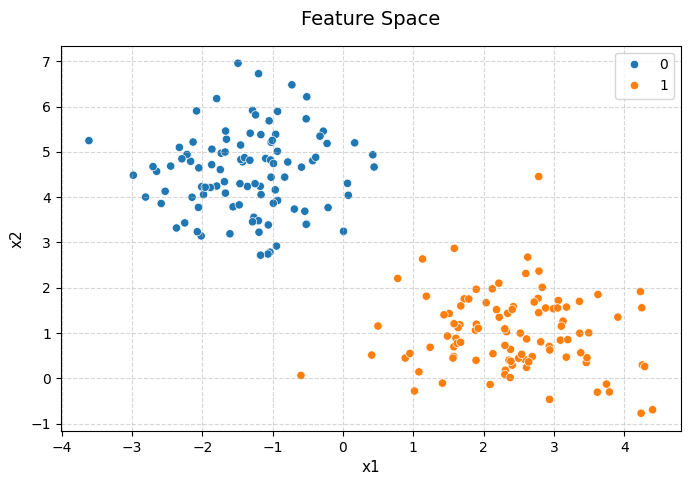

In [135]:
figureXORFeatureSpace = Figure(figsize=(8, 5))

axesFeatureSpace = figureXORFeatureSpace.add_subplot(1, 1, 1)

sns.scatterplot(x=X.T[0], y=X.T[1], hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)

axesFeatureSpace.set_title("Feature Space", fontsize=14, pad=15)
axesFeatureSpace.set_xlabel("x1", fontsize=11)
axesFeatureSpace.set_ylabel("x2", fontsize=11)
axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)

figureXORFeatureSpace.canvas.draw()
display(figureXORFeatureSpace)

In [136]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[ 0.17347079, -1.18315193],
       [ 1.00749383, -1.28746921],
       [ 0.87776316, -0.68075113],
       [-1.32286438,  1.09894901],
       [ 0.98934132, -1.19383038],
       [ 1.79978815, -0.61852374],
       [ 0.91648427, -0.60560784],
       [ 0.66048324, -1.20785331],
       [-1.05497558,  1.27420589],
       [ 1.24021118, -0.98196858],
       [-0.8345244 ,  2.00985287],
       [ 1.2584566 , -0.76805708],
       [-0.25046389,  0.24033116],
       [ 1.10510616, -1.00131341],
       [-0.54295983, -1.37773173],
       [-0.04905194,  1.09905911],
       [ 0.96458817, -0.90298025],
       [ 0.42944904, -1.46462665],
       [ 0.65595096, -0.8712616 ],
       [ 0.54936638, -0.80964598],
       [ 1.16377288, -1.05079203],
       [ 1.09115807, -0.67352321],
       [-0.22312008,  0.77876316],
       [ 0.50645972, -1.16520809],
       [-0.71973914,  0.7058295 ],
       [-1.09755135,  0.93291106],
       [ 1.08678685, -0.51238421],
       [-0.50289188,  0.3232002 ],
       [ 0.47625983,

In [137]:
# On Linearly Separable Dataset

perceptron1 = Perceptron(max_iter=1000, eta0=1.0, random_state=42)
perceptron1.fit(X, y)

Perceptron(random_state=42)

In [138]:
def get_square_axis_limits_DB_focused(
    x, y, decision_boundaries, margin=0.1, margin_after_zero=0.2
):
    """Calculates symmetric x and y limits that cover all data points AND ensure all

    decision boundaries cross the zero-lines with extra extension.

    Parameters:
    -----------
    x : array-like
        Feature values for x-axis.
    y : array-like
        Feature values for y-axis.
    decision_boundaries : list of tuples
        List of (w, b) pairs representing each decision boundary.
        w can be a list/array [w1, w2], and b is a scalar float.
    margin : float, default=0.1
        Percentage margin padding applied around the global bounds.
    margin_after_zero : float, default=0.2
        Extra extension past zero-crossings for boundary lines.

    Returns:
    --------
    min_db_limit : float
        Lower bound for both set_xlim and set_ylim.
    max_db_limit : float
        Upper bound for both set_xlim and set_ylim.
    """
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    # 1. Start with global min/max from data points + origin (0, 0)
    all_critical_points = [
        np.min(x_arr),
        np.max(x_arr),
        np.min(y_arr),
        np.max(y_arr),
        0.0,  # Ensure origin is always included
    ]

    

    # 2. Collect key intercepts for every decision boundary
    for w, b in decision_boundaries:
        w1, w2 = w[0], w[1]

        if w1 == 0 and w2 == 0:
            continue

        # x1-intercept (where x2 = 0): w1*x1 + b = 0 -> x1 = -b / w1
        if w1 != 0:
            x1_intercept = -b / w1
            all_critical_points.append(x1_intercept)
            # Add extra extension past the intercept
            all_critical_points.append(
                x1_intercept * (1.0 + margin_after_zero)
            )

        # x2-intercept (where x1 = 0): w2*x2 + b = 0 -> x2 = -b / w2
        if w2 != 0:
            x2_intercept = -b / w2
            all_critical_points.append(x2_intercept)
            # Add extra extension past the intercept
            all_critical_points.append(
                x2_intercept * (1.0 + margin_after_zero)
            )

    # 3. Find overall min and max across data + intercepts
    global_min = min(all_critical_points)
    global_max = max(all_critical_points)

    # 4. Apply overall plot margin padding
    data_span = global_max - global_min
    padding = data_span * margin if data_span > 0 else 1.0

    min_db_limit = global_min - padding
    max_db_limit = global_max + padding

   

    return min_db_limit, max_db_limit

In [139]:
def generate_line_points(
    w, b, x1_range=(-1000, 1000), x2_range=(-1000, 1000), num_points=500
):
    """Generates 2D coordinates for a decision boundary line w1*x1 + w2*x2 + b = 0.

    Returns:
        (x1_coords_in_range, x2_coords_in_range, x1_coords, x2_coords)
    """
    w1, w2 = w[0], w[1]

    # Case 1: Line is undefined
    if w1 == 0 and w2 == 0:
        raise ValueError(
            "Weights w1 and w2 cannot both be zero. Undefined decision boundary."
        )

    # 1. Generate full line coordinates evaluated across x1_range
    if w2 == 0:  # Vertical line (x1 = -b / w1)
        x1_fixed = -b / w1
        x1_coords = np.full(num_points, x1_fixed)
        x2_coords = np.linspace(x2_range[0], x2_range[1], num_points)
    else:  # Standard or horizontal line
        x1_coords = np.linspace(x1_range[0], x1_range[1], num_points)
        x2_coords = (-w1 * x1_coords - b) / w2

    # 2. Filter points strictly inside both x1_range and x2_range
    mask = (
        (x1_coords >= x1_range[0])
        & (x1_coords <= x1_range[1])
        & (x2_coords >= x2_range[0])
        & (x2_coords <= x2_range[1])
    )

    x1_coords_in_range = x1_coords[mask]
    x2_coords_in_range = x2_coords[mask]

    return (
        x1_coords_in_range,
        x2_coords_in_range
    )

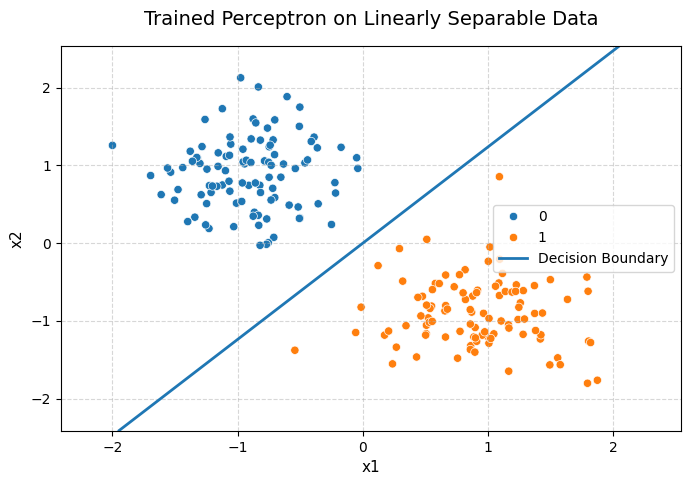

In [140]:
figureXORFeatureSpace = Figure(figsize=(8, 5))

axesFeatureSpace = figureXORFeatureSpace.add_subplot(1, 1, 1)


sns.scatterplot(x=X.T[0], y=X.T[1], hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)
min_limit, max_limit = get_square_axis_limits_DB_focused(X.T[0], X.T[1], decision_boundaries=[(perceptron1.coef_[0], perceptron1.intercept_)])
x0, y0 = generate_line_points(perceptron1.coef_[0], perceptron1.intercept_, x1_range=(min_limit, max_limit), x2_range=(min_limit, max_limit))
sns.lineplot(x=x0, y=y0, ax=axesFeatureSpace, lw=2, label="Decision Boundary")

axesFeatureSpace.set_title("Trained Perceptron on Linearly Separable Data", fontsize=14, pad=15)
axesFeatureSpace.set_xlabel("x1", fontsize=11)
axesFeatureSpace.set_ylabel("x2", fontsize=11)
axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)
axesFeatureSpace.set_xlim(min_limit, max_limit)
axesFeatureSpace.set_ylim(min_limit, max_limit)

figureXORFeatureSpace.canvas.draw()
display(figureXORFeatureSpace)

In [141]:
#XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y= np.array([0, 1, 1, 0])

In [149]:
# On XOR Dataset

perceptron2 = Perceptron(max_iter=100, eta0=0.1, random_state=42, early_stopping=False, tol=None, shuffle=False)
perceptron2.fit(X, y)

Perceptron(eta0=0.1, max_iter=100, random_state=42, shuffle=False, tol=None)

In [148]:
perceptron2.coef_

array([[0., 0.]])

It's a 2D Dataset, but both feature weights are $0$. So, It founds no decision boundary line. Because, the `SKLearn#Perceptron` on the XOR Dataset, over one epoch, $\Delta w = 0 = \Delta b$. 

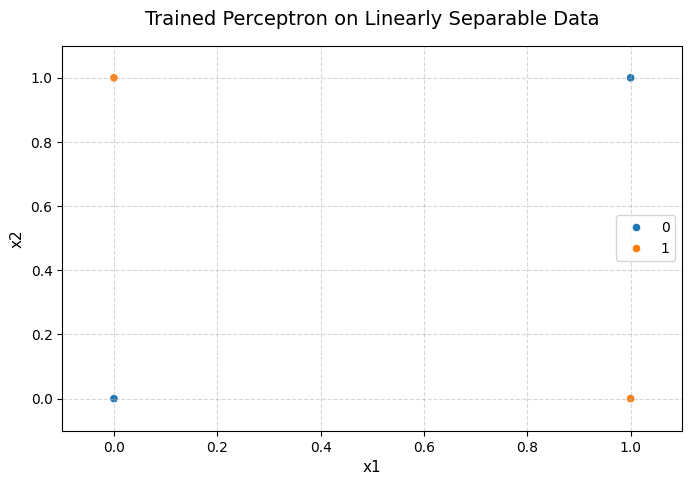

In [150]:
figureXORFeatureSpace = Figure(figsize=(8, 5))

axesFeatureSpace = figureXORFeatureSpace.add_subplot(1, 1, 1)


sns.scatterplot(x=X.T[0], y=X.T[1], hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)
min_limit, max_limit = get_square_axis_limits_DB_focused(X.T[0], X.T[1], decision_boundaries=[(perceptron2.coef_[0], perceptron2.intercept_)])
# x0, y0 = generate_line_points(perceptron2.coef_[0], perceptron2.intercept_, x1_range=(min_limit, max_limit), x2_range=(min_limit, max_limit))
sns.lineplot(x=[], y=[], ax=axesFeatureSpace, lw=2, label="Decision Boundary")

axesFeatureSpace.set_title("Trained Perceptron on Linearly Separable Data", fontsize=14, pad=15)
axesFeatureSpace.set_xlabel("x1", fontsize=11)
axesFeatureSpace.set_ylabel("x2", fontsize=11)
axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)
axesFeatureSpace.set_xlim(min_limit, max_limit)
axesFeatureSpace.set_ylim(min_limit, max_limit)

figureXORFeatureSpace.canvas.draw()
display(figureXORFeatureSpace)